# Calibration curves — RF vs logistic regression

Daily notebook — small experiment, fully reproducible (seed pinned below).

Accuracy isn't everything: when the model says 80%, is it right 80% of the time?

## Setup

In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split, cross_val_score, StratifiedKFold, GridSearchCV
from sklearn.model_selection import learning_curve, validation_curve
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.linear_model import LogisticRegression, LinearRegression, Ridge, Lasso
from sklearn.ensemble import (RandomForestClassifier, RandomForestRegressor,
                              GradientBoostingClassifier, GradientBoostingRegressor,
                              HistGradientBoostingClassifier, VotingClassifier,
                              IsolationForest)
from sklearn.svm import SVC
from sklearn.neighbors import KNeighborsClassifier
from sklearn.naive_bayes import MultinomialNB
from sklearn.cluster import KMeans
from sklearn.decomposition import PCA
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.metrics import (accuracy_score, roc_auc_score, confusion_matrix,
                             classification_report, mean_squared_error,
                             mean_absolute_error, r2_score, silhouette_score)

from sklearn.datasets import load_breast_cancer
from sklearn.calibration import calibration_curve


## Curves

logreg: brier 0.0321
rf: brier 0.0362


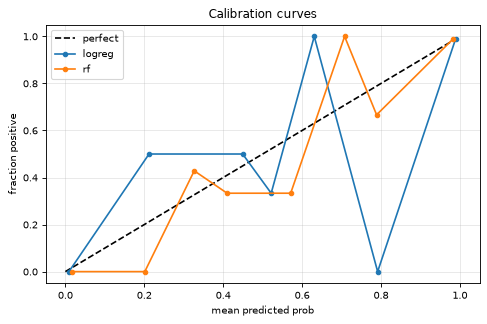

In [ ]:
SEED = 1299
X, y = load_breast_cancer(return_X_y=True)
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.3, random_state=SEED, stratify=y)
models = {"logreg": LogisticRegression(max_iter=5000),
          "rf": RandomForestClassifier(n_estimators=300, random_state=SEED, n_jobs=1)}
fig, ax = plt.subplots()
ax.plot([0, 1], [0, 1], "k--", label="perfect")
for name, m in models.items():
    m.fit(X_train, y_train)
    prob = m.predict_proba(X_test)[:, 1]
    frac_pos, mean_pred = calibration_curve(y_test, prob, n_bins=8)
    ax.plot(mean_pred, frac_pos, marker="o", ms=4, label=name)
    print(f"{name}: brier {np.mean((prob - y_test) ** 2):.4f}")
ax.set_xlabel("mean predicted prob"); ax.set_ylabel("fraction positive")
ax.legend(); ax.set_title("Calibration curves")


## Notes

- Logreg is nearly perfectly calibrated out of the box.
- RF is overconfident at the extremes — the usual story; Platt/isotonic would fix it if it mattered.